[HAMI-core Warn(1463:139666090153792:libvgpu.c:115)]: recursive dlsym : pthread_create



[2026-08-05 10:14:57] [info     ] 检查/训练模型                        path='/home/aiuser/work/PonyOracle V5/transformer_model.json'
datasources={'bar1m': 'bigalpha_2026_stock_bar1m', 'bar5m': 'bigalpha_2026_stock_bar5m', 'bar15m': 'bigalpha_2026_stock_bar15m', 'bar30m': 'bigalpha_2026_stock_bar30m', 'instruments': 'bigalpha_2026_instruments'}
train days=1353 (2019-06-03→2024-12-25)
valid days=62 (2019-03-01→2019-05-31)
无有效标准化缓存（/home/aiuser/work/PonyOracle V5/transformer_model.json 缺失/空白/无 scale_details），正在生成...
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 1m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处理 5m 数据
处

时段,IC
2024-01-15~2024-02-08,-0.0072
2024-09-24~2024-10-08,0.0903

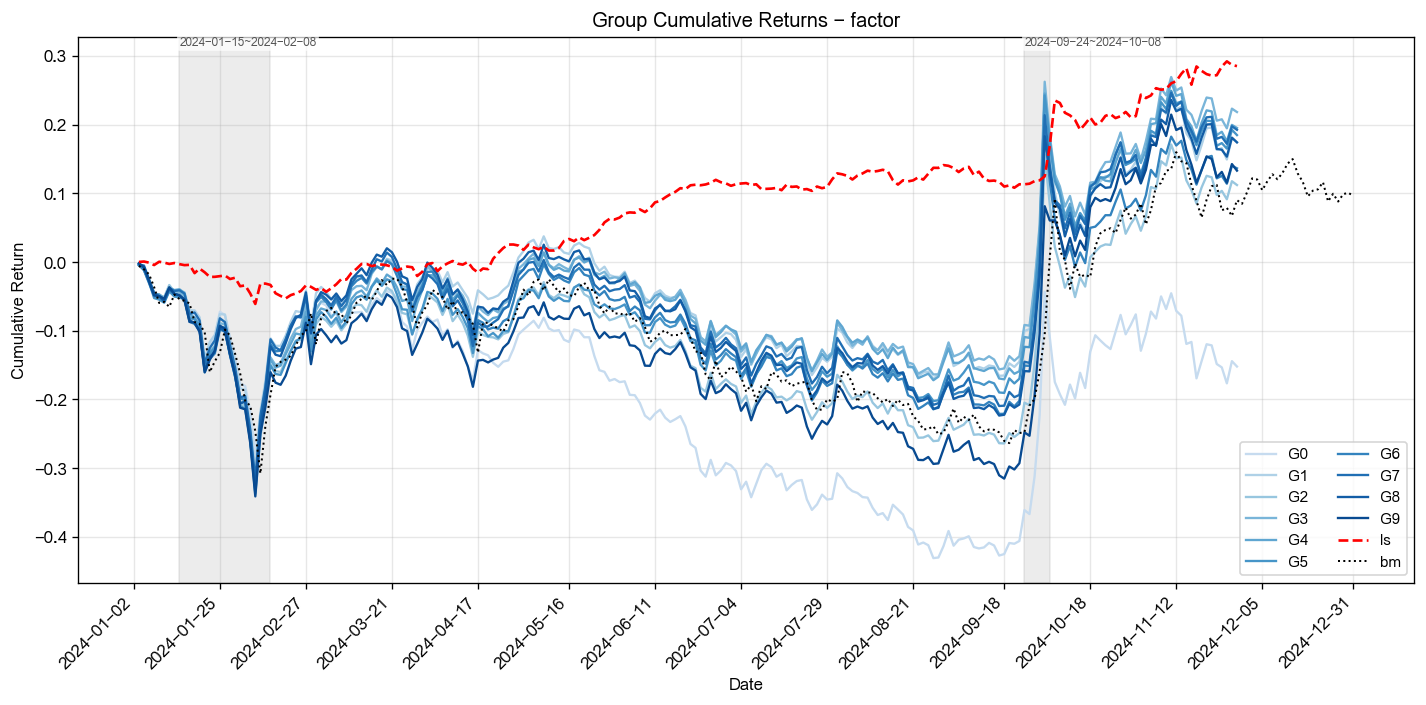
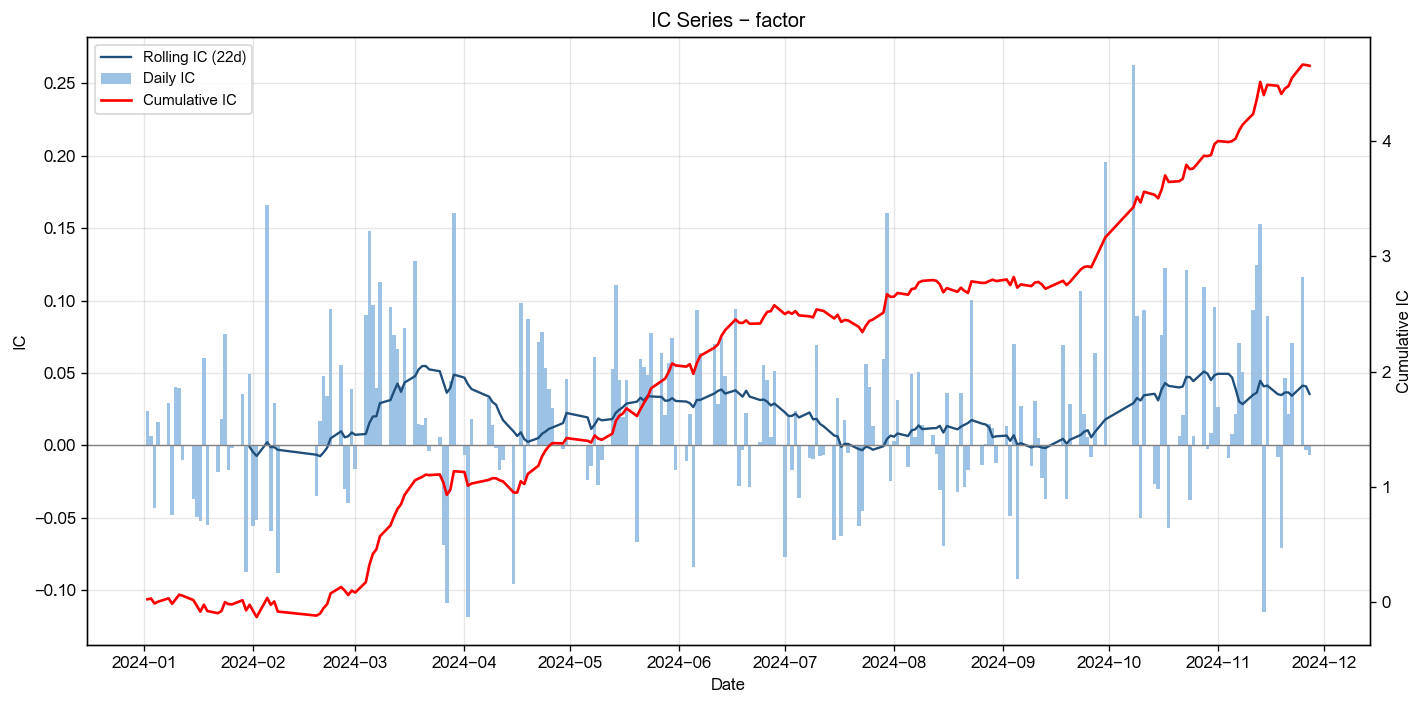
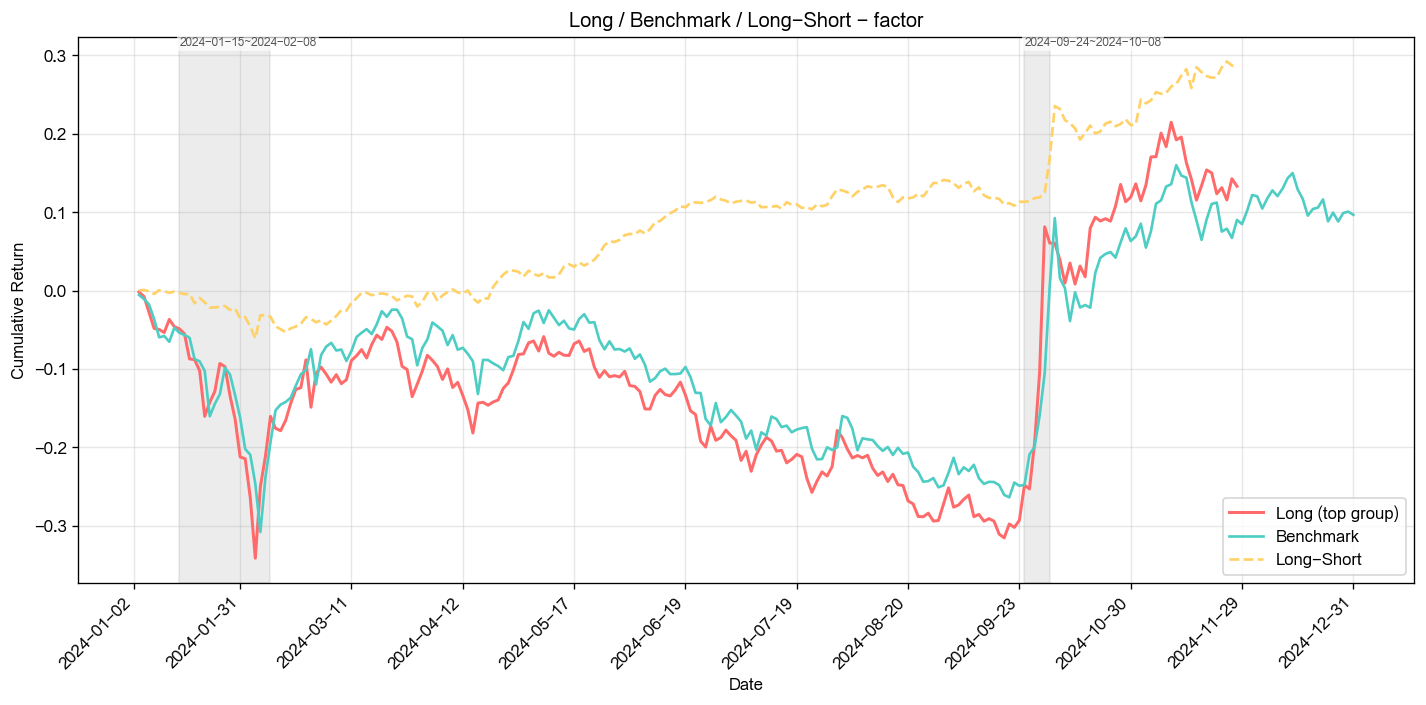
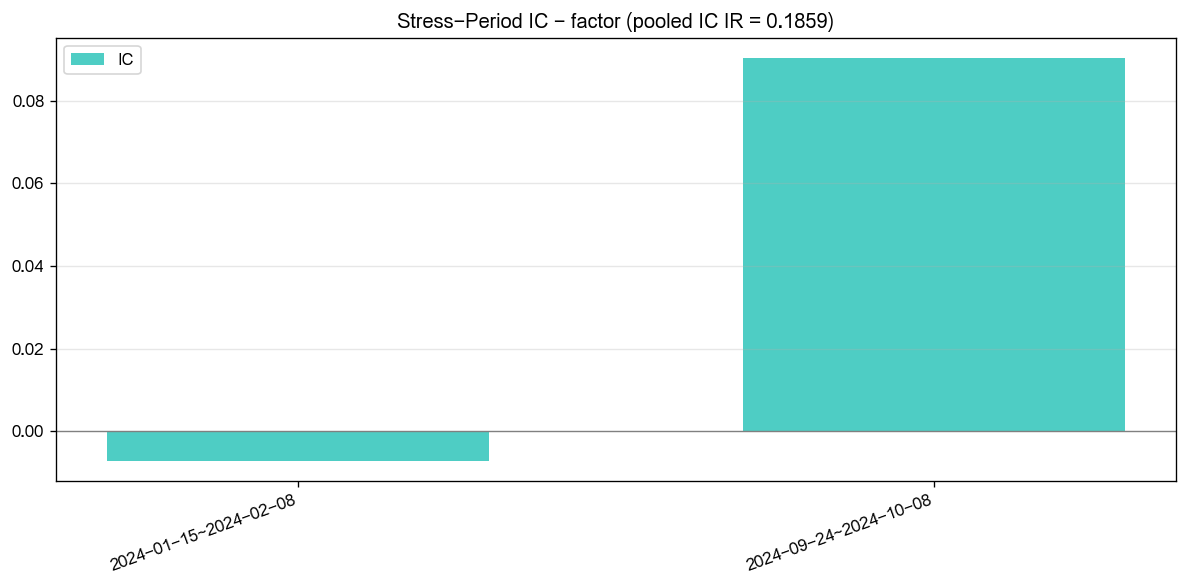
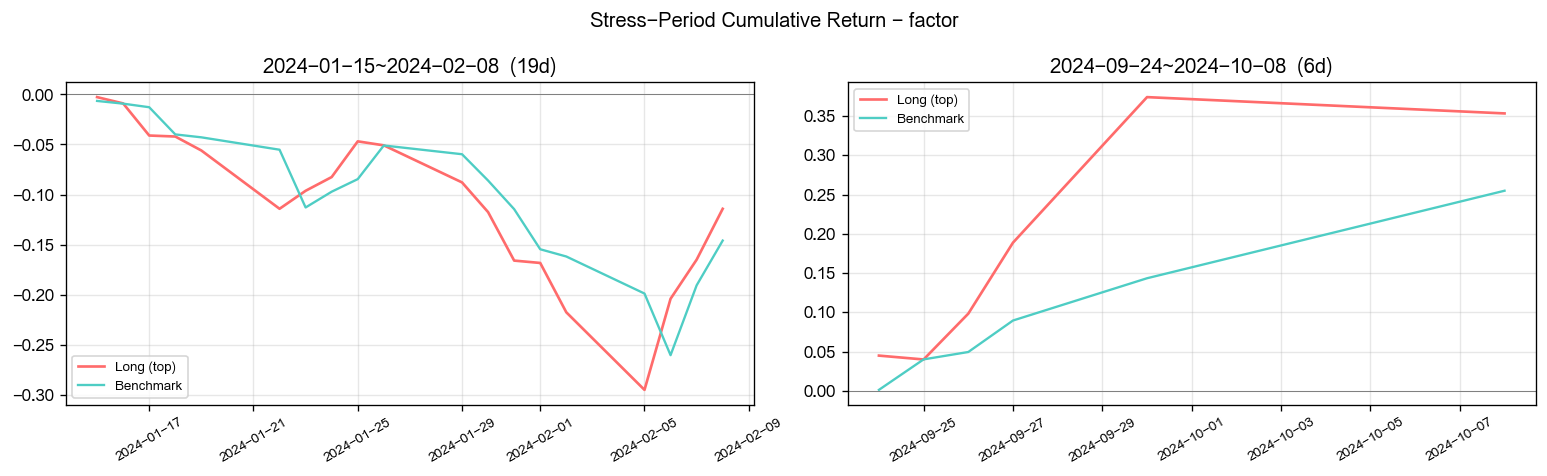

[2026-08-05 13:19:19] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-08-05 13:19:19] [warning  ] 返回的Outputs实例(size=32882767) 大于 64K, 将不会被缓存
[2026-08-05 13:19:19] [info     ] bigalpha_eval.v4 运行完成 [12.335s].


In [1]:
import structlog

from transformer_train import MODEL_PATH, train_and_save
from Predict_Feature import predict_scores  # 逐日轻量路径；每天打印一行

logger = structlog.get_logger()


def main(datasources, start_date, end_date):
    """加载已训练模型，在测试区间打分（逐日特征，不走滚动 Store）。"""
    logger.info(
        "开始推理",
        start=str(start_date),
        end=str(end_date),
        model=MODEL_PATH,
        ds=list(datasources.keys()),
    )
    result = predict_scores(datasources, start_date, end_date, MODEL_PATH)
    logger.info(
        "打分完成",
        rows=len(result),
        days=result["date"].nunique() if len(result) else 0,
        instruments=result["instrument"].nunique() if len(result) else 0,
    )
    return result


if __name__ == "__main__":
    from bigmodule import M

    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m",
        "bar5m": "bigalpha_2026_stock_bar5m",
        "bar15m": "bigalpha_2026_stock_bar15m",
        "bar30m": "bigalpha_2026_stock_bar30m",
    }

    logger.info("检查/训练模型", path=MODEL_PATH)
    train_and_save(datasources)

    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    logger.info("开始打分(仅加载权重, 不重训)", start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())

    logger.info("开始回测评估")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)